Number of features: 13

Features:
['EURUSD_change_lag_1', 'EURUSD_change_lag_2', 'EURUSD_change_lag_3', 'EURUSD_change_lag_4', 'EURUSD_change_lag_5', 'EURUSD_change_lag_6', 'EURUSD_change_lag_7', 'EURUSD_change_lag_8', 'EURUSD_change_lag_9', 'EURUSD_change_lag_10', 'diff2Y_lag_1', 'diff10Y_lag_1', 'diffCPI_lag_1']

Training samples: 8002
Testing samples : 2001

RANDOM FOREST RESULTS (predicting change)
RMSE = 0.004523
MAE  = 0.003060

NAIVE MODEL
RMSE = 0.004516
MAE  = 0.003044

FEATURE IMPORTANCE
                 Feature  Importance
6    EURUSD_change_lag_7    0.137874
0    EURUSD_change_lag_1    0.127694
5    EURUSD_change_lag_6    0.101319
1    EURUSD_change_lag_2    0.076906
3    EURUSD_change_lag_4    0.074448
9   EURUSD_change_lag_10    0.073434
2    EURUSD_change_lag_3    0.071553
8    EURUSD_change_lag_9    0.070010
11         diff10Y_lag_1    0.067523
7    EURUSD_change_lag_8    0.067295
10          diff2Y_lag_1    0.060661
4    EURUSD_change_lag_5    0.047440
12         diffC

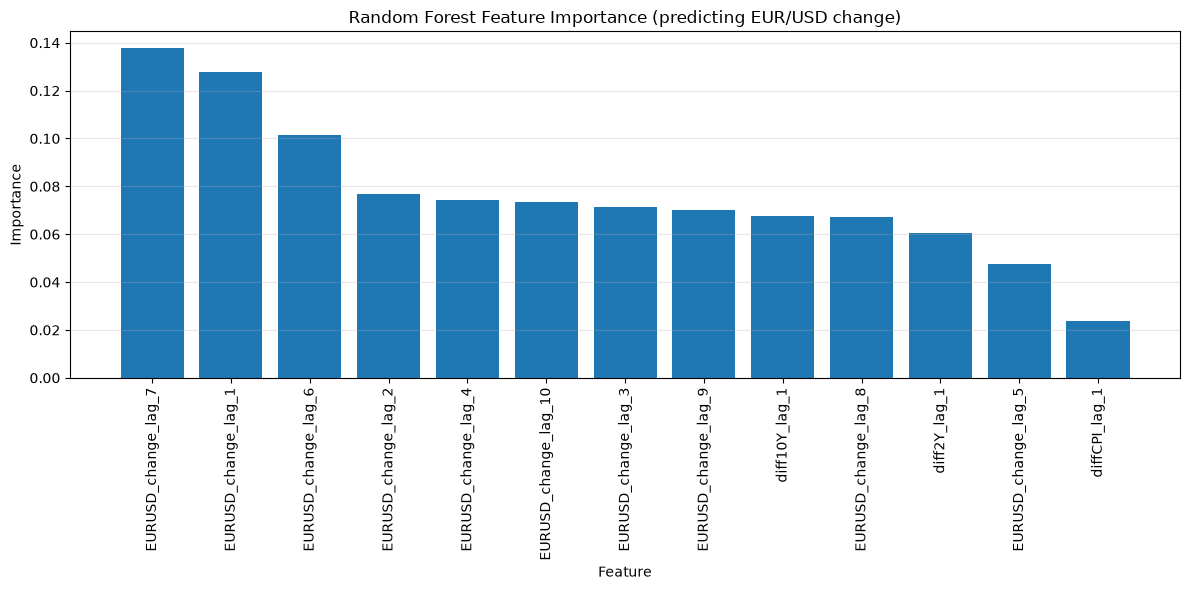

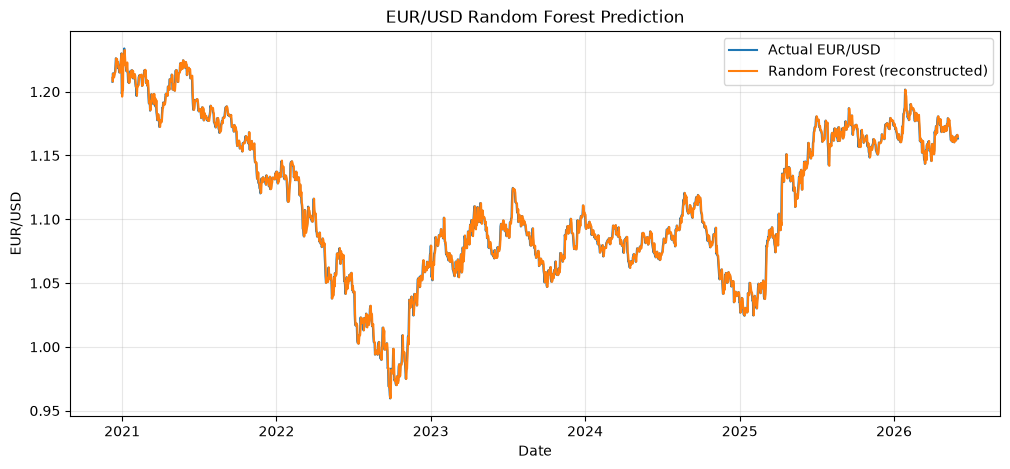

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ucitavanje

DATA_PATH = "data/sve.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


# pravljenje parametara

df["diff2Y"] = df["USA2Y"] - df["GER2Y"]
df["diff10Y"] = df["USA10Y"] - df["GER10Y"]
df["diffCPI"] = df["CPI"] - df["HICP"]


# 
df["EURUSD_change"] = df["EURUSD"].diff()


# ============================================================
# 4. CREATE LAGGED FEATURES
# ============================================================

N_LAGS = 10

data = pd.DataFrame()

# Past EUR/USD changes (not past levels)
for lag in range(1, N_LAGS + 1):
    data[f"EURUSD_change_lag_{lag}"] = df["EURUSD_change"].shift(lag)


# Economic variables
economic_variables = [
    "diff2Y",
    "diff10Y",
    "diffCPI"
]

for variable in economic_variables:
    data[f"{variable}_lag_1"] = df[variable].shift(1)


# Targets (keep both: the change to train on, the level to score with)
data["EURUSD_change"] = df["EURUSD_change"]
data["EURUSD"] = df["EURUSD"]

# Remove rows with NaN caused by lagging / differencing
data = data.dropna().reset_index(drop=True)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

X = data.drop(columns=["EURUSD_change", "EURUSD"])
y = data["EURUSD_change"]

print("Number of features:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# Do not shuffle time-series data.

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 7. RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 8. TRAIN
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 9. PREDICT THE CHANGE, RECONSTRUCT THE PRICE LEVEL
# ============================================================

pred_change = model.predict(X_test)

# predicted price_t = actual price_{t-1} + predicted change
prev_price = data["EURUSD"].iloc[split - 1: len(data) - 1].values
prediction = prev_price + pred_change
actual_price = data["EURUSD"].iloc[split:].values


# ============================================================
# 10. EVALUATION (on price level, so it's comparable to before)
# ============================================================

rmse = np.sqrt(
    mean_squared_error(actual_price, prediction)
)

mae = mean_absolute_error(
    actual_price,
    prediction
)

print("\n==============================")
print("RANDOM FOREST RESULTS (predicting change)")
print("==============================")

print(f"RMSE = {rmse:.6f}")
print(f"MAE  = {mae:.6f}")


# ============================================================
# 11. NAIVE BASELINE
# ============================================================

# Predict EUR/USD using previous day's EUR/USD (no change)

naive_prediction = prev_price

naive_rmse = np.sqrt(
    mean_squared_error(actual_price, naive_prediction)
)

naive_mae = mean_absolute_error(
    actual_price,
    naive_prediction
)

print("\n==============================")
print("NAIVE MODEL")
print("==============================")

print(f"RMSE = {naive_rmse:.6f}")
print(f"MAE  = {naive_mae:.6f}")


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance_df)


# ============================================================
# 13. PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.title("Random Forest Feature Importance (predicting EUR/USD change)")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 14. PLOT ACTUAL VS PREDICTION (reconstructed price level)
# ============================================================

# data row 0 corresponds to df row (len(df) - len(data)) -- computed
# dynamically rather than assumed as N_LAGS, since .diff() adds one
# more leading NaN on top of the N_LAGS lag columns.
dropped_rows = len(df) - len(data)
test_dates = df["Date"].iloc[dropped_rows + split:]

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_price,
    label="Actual EUR/USD"
)

plt.plot(
    test_dates,
    prediction,
    label="Random Forest (reconstructed)"
)

plt.title("EUR/USD Random Forest Prediction")
plt.xlabel("Date")
plt.ylabel("EUR/USD")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Text(0.5, 1.0, 'EUR/USD Prediction for the last 500 days')

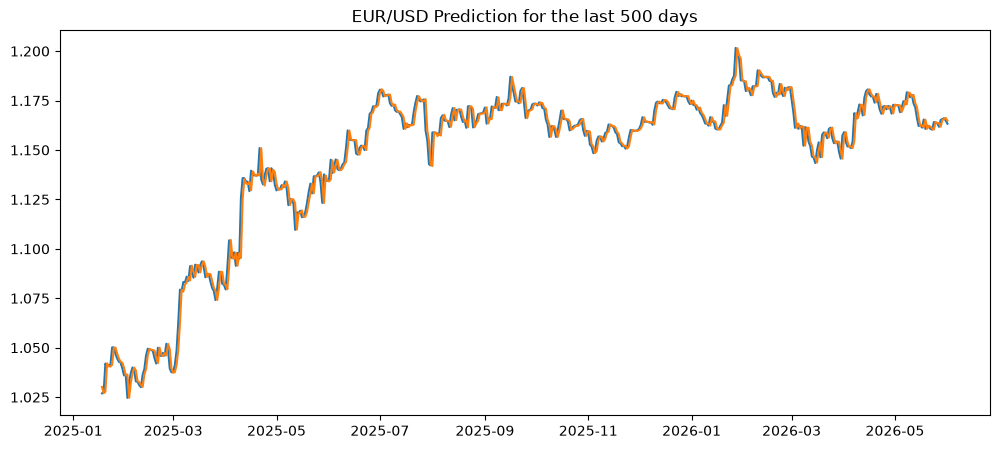

In [2]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_dates[-500::],
    actual_price[-500::],
    label="Actual EUR/USD"
)

plt.plot(
    test_dates[-500::],
    prediction[-500::],
    label="Random Forest (reconstructed)"
)
plt.title("EUR/USD Prediction for the last 500 days")


Data after creating lags:
   USDJPY_change_lag_1  USDJPY_change_lag_2  USDJPY_change_lag_3  \
0                -0.30                 1.16                 1.00   
1                 1.21                -0.30                 1.16   
2                 1.53                 1.21                -0.30   
3                 2.40                 1.53                 1.21   
4                 1.90                 2.40                 1.53   

   USDJPY_change_lag_4  USDJPY_change_lag_5  USDJPY_change_lag_6  \
0                 0.40                 0.90                -0.85   
1                 1.00                 0.40                 0.90   
2                 1.16                 1.00                 0.40   
3                -0.30                 1.16                 1.00   
4                 1.21                -0.30                 1.16   

   USDJPY_change_lag_7  USDJPY_change_lag_8  USDJPY_change_lag_9  \
0                 2.38                 0.37                -0.69   
1                -0

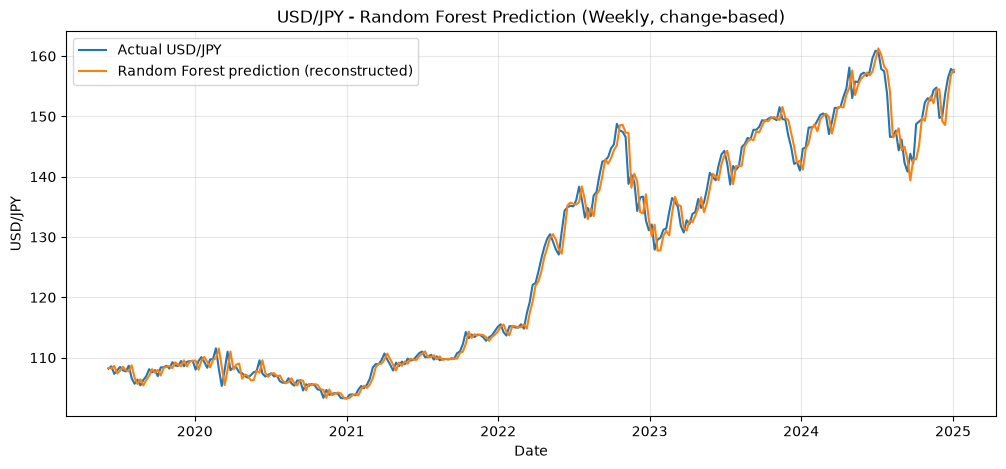


Feature importance:
                Feature  Importance
4   USDJPY_change_lag_5    0.177626
0   USDJPY_change_lag_1    0.129239
1   USDJPY_change_lag_2    0.126442
9  USDJPY_change_lag_10    0.111007
7   USDJPY_change_lag_8    0.107051
3   USDJPY_change_lag_4    0.084503
2   USDJPY_change_lag_3    0.078395
8   USDJPY_change_lag_9    0.073991
5   USDJPY_change_lag_6    0.058521
6   USDJPY_change_lag_7    0.053225


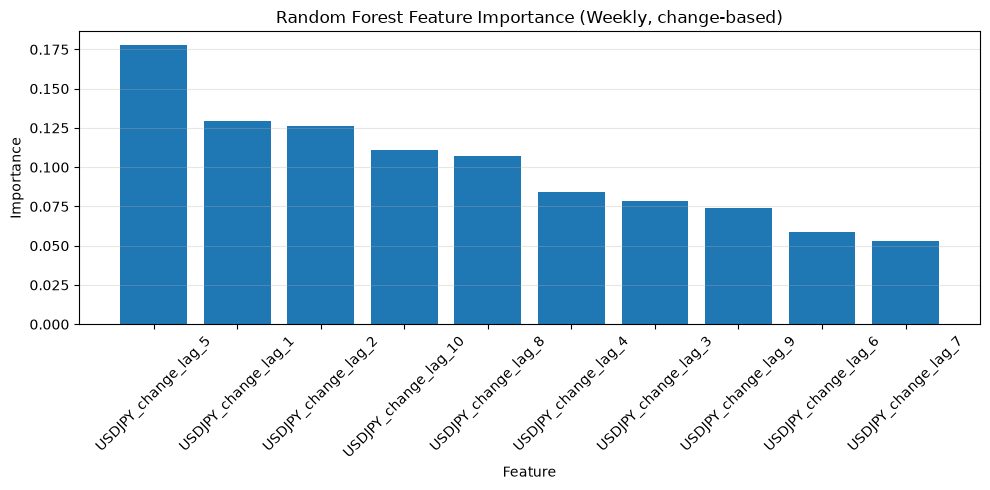

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = "data/usdjpy.csv"

df = pd.read_csv(DATA_PATH)

# Convert Date to datetime, sort, and set it as the index.
# .loc["...":"..."] only slices by date if Date IS the index --
# as a plain column it silently falls back to positional slicing,
# which is why the old cutoff wasn't actually filtering by date.
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.set_index("Date")

# Shorten the dataset (now works correctly)
df = df.loc[:"2024-12-31"]

# Resample to weekly (last observation of each week, Friday close)
df = df.resample("W-FRI").last()


# ============================================================
# 2. TARGET: PREDICT THE CHANGE, NOT THE LEVEL
# ============================================================
# A Random Forest can only output values it saw in the training
# target range -- it can't extrapolate past the highest/lowest
# USD/JPY level it was trained on. That's why the price-level
# version went flat once USD/JPY broke into new highs.
# Predicting the week-over-week CHANGE removes that ceiling: the
# final price is reconstructed as (previous actual price + predicted
# change), and the previous actual price is real data, not something
# the model has to output -- so the reconstructed price is free to
# go anywhere.

df["USDJPY_change"] = df["Close"].diff()


# ============================================================
# 3. CREATE LAGGED FEATURES
# ============================================================

N_LAGS = 10

data = pd.DataFrame()

for lag in range(1, N_LAGS + 1):
    data[f"USDJPY_change_lag_{lag}"] = df["USDJPY_change"].shift(lag)

# Targets (keep both: the change to train on, the level to score with)
data["USDJPY_change"] = df["USDJPY_change"]
data["USDJPY"] = df["Close"]

# Keep the (now weekly) dates aligned with each row before dropping NaNs
data["Date"] = df.index

# Remove rows containing NaN values
data = data.dropna().reset_index(drop=True)

print("\nData after creating lags:")
print(data.head())


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop(columns=["USDJPY_change", "USDJPY", "Date"])
y_target = data["USDJPY_change"]

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# Do NOT randomly shuffle time-series data.

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y_target.iloc[:split]
y_test  = y_target.iloc[split:]

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 6. CREATE RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 7. TRAIN
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 8. PREDICT THE CHANGE, RECONSTRUCT THE PRICE LEVEL
# ============================================================

pred_change = model.predict(X_test)

# predicted price_t = actual price_{t-1} + predicted change
prev_price = data["USDJPY"].iloc[split - 1: len(data) - 1].values
prediction = prev_price + pred_change
actual_price = data["USDJPY"].iloc[split:].values


# ============================================================
# 9. EVALUATION (on price level, so it's comparable to before)
# ============================================================

rmse = np.sqrt(
    mean_squared_error(actual_price, prediction)
)

mae = mean_absolute_error(
    actual_price,
    prediction
)

print("\n==============================")
print("RANDOM FOREST RESULTS (weekly, predicting change)")
print("==============================")

print(f"RMSE = {rmse:.6f}")
print(f"MAE  = {mae:.6f}")


# ============================================================
# 10. NAIVE BASELINE
# ============================================================

# Predict this week's USD/JPY using last week's USD/JPY (no change)

naive_prediction = prev_price

naive_rmse = np.sqrt(
    mean_squared_error(actual_price, naive_prediction)
)

naive_mae = mean_absolute_error(
    actual_price,
    naive_prediction
)

print("\n==============================")
print("NAIVE MODEL (weekly)")
print("==============================")

print(f"RMSE = {naive_rmse:.6f}")
print(f"MAE  = {naive_mae:.6f}")


# ============================================================
# 11. PLOT ACTUAL VS PREDICTED
# ============================================================

test_dates = data["Date"].iloc[split:]

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_price,
    label="Actual USD/JPY"
)

plt.plot(
    test_dates,
    prediction,
    label="Random Forest prediction (reconstructed)"
)

plt.title("USD/JPY - Random Forest Prediction (Weekly, change-based)")
plt.xlabel("Date")
plt.ylabel("USD/JPY")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature importance:")
print(importance_df)


# ============================================================
# 13. PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance (Weekly, change-based)")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()